In [ ]:
!pip install -q numpy matplotlib scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
# Create blobs of data totalling 100 samples with 2 centers, with some id of random state to ensure its the same every time, where X is the data point
# and y is if its part of the first center or the second
X, y = make_blobs(n_samples=100, centers=2, random_state=1)

In [ ]:
# change y to -1 and +1
y = np.where(y == 0, -1, 1)

In [ ]:
print(X.shape)
print(y.shape)

(100, 2)
(100,)


Text(0.5, 1.0, 'Collections data')

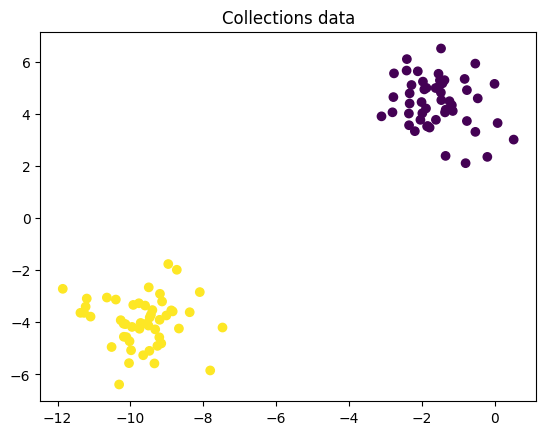

In [ ]:
# graph the data
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Collections data")

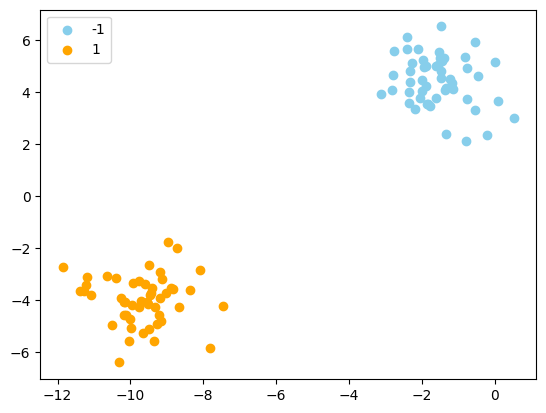

In [ ]:
# take all features in X where its label is -1, then give me its 0th index, then the same but returning its 1st index
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='skyblue', label='-1')

# take all features in X where its label is 1, then give me its 0th index, then the same but returning its 1st index
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='orange', label='1')
plt.legend()


In [ ]:
class SVM:
  def __init__(self, learn_rate: int, lambda_param: int, epochs: int):
    self.learn_rate = learn_rate
    self.lambda_param = lambda_param
    self.epochs = epochs
    self.weight = None
    self.bias = 0

  def fit(self, X, y):
    num_features = X.shape[1]
    self.weight = np.zeros(num_features)
    for _ in range(self.epochs):
      for idx,s in enumerate(X):
        # dot product to calculate scalar score
        score = y[idx] * (np.dot(self.weight, X[idx]) + self.bias)
        # correct sign and far enough away from margin
        if score >= 1:
          self.weight -= self.learn_rate * (self.weight * self.lambda_param)
        # not far enough away from margin, or wrong sign and not far enough away from margin (this covers both cases on the left side of hinge function ==> y * f(x) < 1)
        else:
          self.weight = self.weight - self.learn_rate * (self.weight * self.lambda_param - X[idx] * y[idx])
          self.bias += self.learn_rate * y[idx]

  def predict(self,X):
    # matrix multiplacation to find the total output array
    array_output = np.dot(X, self.weight) + self.bias
    # expression for item in iterable if condition
    return [1 if pred > 0 else -1 for pred in array_output]

  def predict_single(self,x):
    score = np.dot(self.weight, x) + self.bias
    return [1 if score > 0 else -1]

  # evaluates percentage of correct predictions
  def evaluate(self,y_pred,y):
    total = len(y)
    correct = 0
    for i in range(total):
      if y_pred[i] == y[i]:
        correct += 1

    return correct/total

  def return_param(self):
    return self.weight,self.bias

In [ ]:
sample_SVM = SVM(learn_rate=0.001,lambda_param=0.1,epochs=10)

In [ ]:
sample_SVM.fit(X,y)

In [ ]:
y_pred = sample_SVM.predict(X)

In [ ]:
sample_SVM.evaluate(y_pred,y)

1.0

In [ ]:
# predict any random sample
x = (-8,-2)
sample_SVM.predict_single(x)

[1]

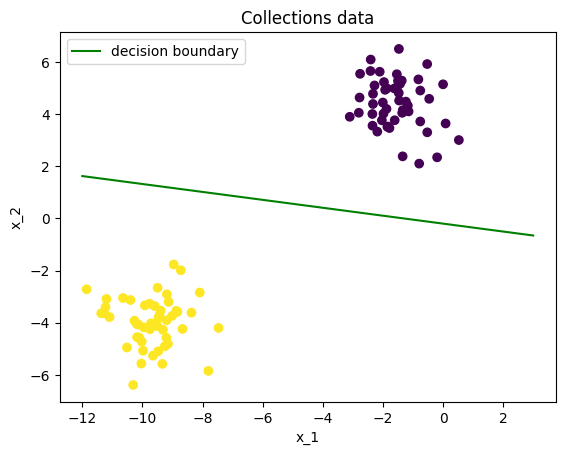

In [ ]:
# graph the data
weight,bias = sample_SVM.return_param()
x_1 = np.arange(-12,4)
x_2 = -(weight[0]/weight[1]) * x_1 - bias/weight[1]

plt.scatter(X[:,0], X[:,1], c=y)
plt.plot(x_1,x_2, color='green', label='decision boundary')
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("Collections data")
plt.legend()

In [ ]:
# Using sk.learn
model = SVC(kernel='linear', C=10)  # C is inverse regularization strength, lambda = 0.1
model.fit(X,y)

y_pred = model.predict(X)

In [ ]:
accuracy = accuracy_score(y, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0
